# Actividad 04 - EDA de la Region Pampeana
## Analisis del dataset meteorologico del SMN

Esta notebook responde las preguntas de la actividad trabajando unicamente con la Region Pampeana.

Provincias incluidas: BUENOS AIRES, CORDOBA, SANTA FE, ENTRE RIOS, LA PAMPA y CAPITAL FEDERAL.

Importante: el dataset usa nombres de provincias en mayusculas y sin tildes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

pd.set_option('display.max_columns', None)
ruta = '../../Datasets/smn_historico.csv'
df = pd.read_csv(ruta)
df.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


## 1. Revision inicial y filtro regional

Primero revisamos las provincias disponibles y luego filtramos exclusivamente las provincias de la Region Pampeana.

In [2]:
print('Dimensiones del dataset:', df.shape)
print('Provincias disponibles:')
print(sorted(df['provincia'].dropna().unique()))

provincias_pampeana = [
    'BUENOS AIRES', 'CORDOBA', 'SANTA FE',
    'ENTRE RIOS', 'LA PAMPA', 'CAPITAL FEDERAL'
]

df_region = df[df['provincia'].isin(provincias_pampeana)].copy()
print('Dimensiones de la Region Pampeana:', df_region.shape)
print('Provincias filtradas:', sorted(df_region['provincia'].dropna().unique()))
display(df_region['provincia'].value_counts().rename_axis('provincia').to_frame('registros'))

Dimensiones del dataset: (1176, 16)
Provincias disponibles:
['ANTARTIDA', 'BUENOS AIRES', 'CAPITAL FEDERAL', 'CATAMARCA', 'CHACO', 'CHUBUT', 'CORDOBA', 'CORRIENTES', 'ENTRE RIOS', 'FORMOSA', 'JUJUY', 'LA PAMPA', 'LA RIOJA', 'MENDOZA', 'MISIONES', 'NEUQUEN', 'RIO NEGRO', 'SALTA', 'SAN JUAN', 'SAN LUIS', 'SANTA CRUZ', 'SANTA FE', 'SANTIAGO DEL ES', 'TIERRA DEL FUEG', 'TUCUMAN']
Dimensiones de la Region Pampeana: (480, 16)
Provincias filtradas: ['BUENOS AIRES', 'CAPITAL FEDERAL', 'CORDOBA', 'ENTRE RIOS', 'LA PAMPA', 'SANTA FE']


,registros
provincia,
BUENOS AIRES,240
CORDOBA,96
SANTA FE,60
ENTRE RIOS,36
CAPITAL FEDERAL,24
LA PAMPA,24


## 2. Preparacion de variables numericas

El archivo contiene el texto `S/D` para datos no disponibles. Lo convertimos a `NaN` antes de calcular medias, desvio, correlaciones y outliers.

In [ ]:
columnas_numericas = [
    'altura', 'LAT_decimal', 'LON_decimal', 'prec_sup_1mm',
    'humedad', 'nubosidad', 'prec_mm', 'temp',
    'temp_max', 'temp_min', 'viento'
]

for columna in columnas_numericas:
    df_region[columna] = pd.to_numeric(df_region[columna], errors='coerce') # 'coerce' significa que los valores no convertibles se establecerán como NaN

print('Valores faltantes luego de convertir S/D:')
display(df_region[columnas_numericas].isna().sum().to_frame('faltantes'))

Valores faltantes luego de convertir S/D:


,faltantes
altura,0
LAT_decimal,0
LON_decimal,0
prec_sup_1mm,5
humedad,3
nubosidad,3
prec_mm,5
temp,3
temp_max,13
temp_min,25


## 3. Pregunta 1: cantidad de estaciones meteorologicas

Contamos estaciones unicas. Como cada estacion tiene doce meses, no contamos filas sino identificadores de estacion. Usamos `NroOACI` cuando esta disponible y `estacion` como respaldo.

In [4]:
identificador_estacion = df_region['NroOACI'].fillna(df_region['estacion'])
cantidad_estaciones = identificador_estacion.nunique()
print('Estaciones unicas:', cantidad_estaciones)
print('Opcion:', '>= 40' if cantidad_estaciones >= 40 else 'entre 31 y 40' if cantidad_estaciones >= 31 else 'entre 21 y 30' if cantidad_estaciones >= 21 else 'entre 11 y 20' if cantidad_estaciones >= 11 else '<= 10')

Estaciones unicas: 40
Opcion: >= 40


## 4. Pregunta 2: altura media de las estaciones

Calculamos la media sobre estaciones unicas, no sobre las 12 filas mensuales repetidas.

In [5]:
estaciones_region = df_region.assign(estacion_id=identificador_estacion).drop_duplicates('estacion_id')
altura_media = estaciones_region['altura'].mean()
print(f'Altura media: {altura_media:.2f} m')
print('Opcion:', '<100 m' if altura_media < 100 else 'entre 101 m y 300 m' if altura_media <= 300 else 'entre 301 m y 500 m' if altura_media <= 500 else 'entre 501 m y 1000 m' if altura_media <= 1000 else '>1000 m')

Altura media: 134.55 m
Opcion: entre 101 m y 300 m


## 5. Preguntas 3 y 4: temperatura media y desvio estandar

La temperatura se calcula sobre los registros mensuales disponibles de la region.

In [6]:
temperatura_media = df_region['temp'].mean()
temperatura_desvio = df_region['temp'].std()
print(f'Temperatura media: {temperatura_media:.2f} °C')
print('Opcion temperatura:', '<10 °C' if temperatura_media < 10 else 'entre 10.1 °C y 15 °C' if temperatura_media <= 15 else 'entre 15.1 °C y 20 °C' if temperatura_media <= 20 else 'entre 20.1 °C y 25 °C' if temperatura_media <= 25 else '>25 °C')
print(f'Desvio estandar de temperatura: {temperatura_desvio:.2f} °C')
print('Opcion desvio:', 'menor que 5 °C' if temperatura_desvio < 5 else 'entre 5 °C y 10 °C' if temperatura_desvio <= 10 else 'mayor que 10 °C')

Temperatura media: 16.55 °C
Opcion temperatura: entre 15.1 °C y 20 °C
Desvio estandar de temperatura: 5.19 °C
Opcion desvio: entre 5 °C y 10 °C


## 6. Pregunta 5: mes con mayor precipitacion media

Agrupamos por mes y calculamos la media regional de `prec_mm`. Reordenamos los meses cronologicamente.

Precipitacion media por mes:


,prec_mm_media
mes_txt,
Ene,112.50
Feb,112.68
Mar,113.37
Abr,97.01
May,55.33
Jun,35.87
Jul,36.09
Ago,40.87
Sep,55.14


Mes con mayor precipitacion media: Mar


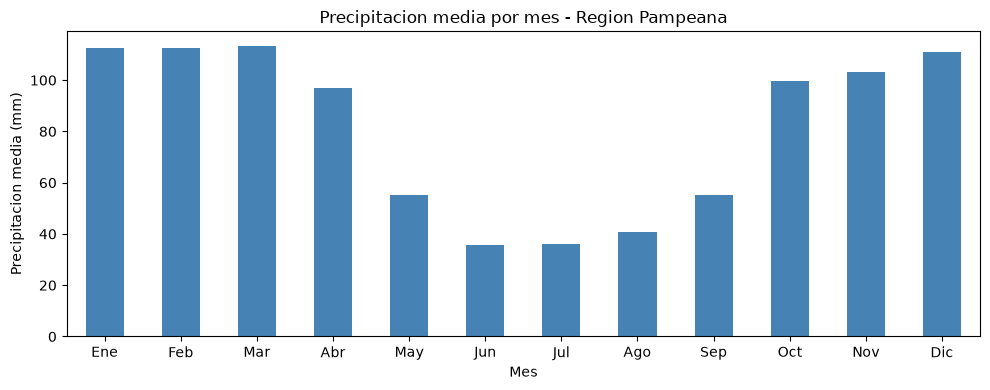

In [7]:
orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
precipitacion_por_mes = df_region.groupby('mes_txt')['prec_mm'].mean().reindex(orden_meses)
mes_mayor_precipitacion = precipitacion_por_mes.idxmax()
print('Precipitacion media por mes:')
display(precipitacion_por_mes.to_frame('prec_mm_media').round(2))
print('Mes con mayor precipitacion media:', mes_mayor_precipitacion)

precipitacion_por_mes.plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.ylabel('Precipitacion media (mm)')
plt.xlabel('Mes')
plt.title('Precipitacion media por mes - Region Pampeana')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Pregunta 6: provincia con mayor temperatura media

Calculamos la media de `temp` agrupando por provincia.

In [8]:
temperatura_por_provincia = df_region.groupby('provincia')['temp'].mean().sort_values(ascending=False)
provincia_mayor_temperatura = temperatura_por_provincia.idxmax()
print('Temperatura media por provincia:')
display(temperatura_por_provincia.to_frame('temp_media').round(2))
print('Provincia con mayor temperatura media:', provincia_mayor_temperatura)

Temperatura media por provincia:


,temp_media
provincia,
SANTA FE,18.48
ENTRE RIOS,18.40
CAPITAL FEDERAL,18.07
CORDOBA,17.33
LA PAMPA,15.96
BUENOS AIRES,15.36


Provincia con mayor temperatura media: SANTA FE


## 8. Pregunta 7: deteccion de outliers

Aplicamos la regla del rango intercuartilico (IQR) a `temp` y `prec_mm`. Un valor es posible outlier si esta por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR.

In [9]:
def resumen_iqr(data, columna):
    serie = data[columna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (serie < limite_inferior) | (serie > limite_superior)
    return {
        'variable': columna, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'cantidad_outliers': int(mascara.sum())
    }

outliers = pd.DataFrame([
    resumen_iqr(df_region, 'temp'),
    resumen_iqr(df_region, 'prec_mm')
])
display(outliers.round(2))

hay_outlier_temp = outliers.loc[outliers['variable'].eq('temp'), 'cantidad_outliers'].iloc[0] > 0
hay_outlier_prec = outliers.loc[outliers['variable'].eq('prec_mm'), 'cantidad_outliers'].iloc[0] > 0
if hay_outlier_temp and hay_outlier_prec:
    respuesta_outliers = 'temperatura y precipitacion'
elif hay_outlier_temp:
    respuesta_outliers = 'temperatura'
elif hay_outlier_prec:
    respuesta_outliers = 'precipitacion'
else:
    respuesta_outliers = 'ninguna'
print('Opcion outliers:', respuesta_outliers)

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers
0,temp,12.10,21.2,9.10,-1.55,34.85,0
1,prec_mm,52.85,111.4,58.55,-34.98,199.23,0


Opcion outliers: ninguna


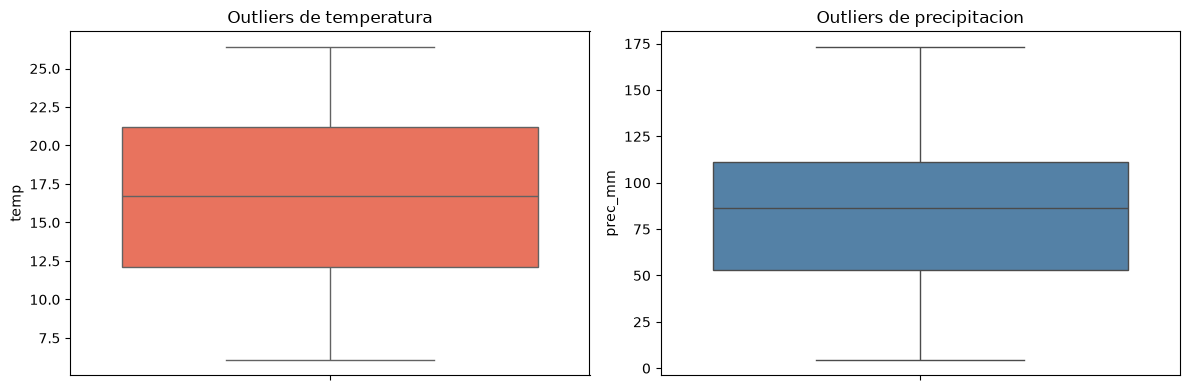

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_region, y='temp', ax=axes[0], color='tomato')
axes[0].set_title('Outliers de temperatura')
sns.boxplot(data=df_region, y='prec_mm', ax=axes[1], color='steelblue')
axes[1].set_title('Outliers de precipitacion')
plt.tight_layout()
plt.show()

## 9. Pregunta 8: correlacion de Spearman entre altura y temperatura

Para evitar repetir doce veces cada estacion, usamos una fila por estacion con la altura y la temperatura media de sus meses disponibles. Spearman mide la relacion monotona entre los rangos de ambas variables.

In [11]:
estacion_resumen = (
    df_region.assign(estacion_id=identificador_estacion)
    .groupby(['estacion_id', 'provincia'], dropna=False)
    .agg(altura=('altura', 'first'), temp_media=('temp', 'mean'))
    .dropna(subset=['altura', 'temp_media'])
)

rho_spearman, p_valor_spearman = spearmanr(estacion_resumen['altura'], estacion_resumen['temp_media'])
print(f'Coeficiente de Spearman: {rho_spearman:.4f}')
print(f'p-valor: {p_valor_spearman:.4g}')
if rho_spearman < -0.2:
    print('Conclusion: existe una relacion inversa; a mayor altitud tienden a registrarse temperaturas mas bajas.')
elif rho_spearman > 0.2:
    print('Conclusion: ambas variables tienden a crecer juntas.')
else:
    print('Conclusion: no hay una relacion monotona apreciable.')

Coeficiente de Spearman: -0.1745
p-valor: 0.2815
Conclusion: no hay una relacion monotona apreciable.


## 10. Pregunta 9: eta cuadrado entre provincia y precipitacion

Eta cuadrado mide que proporcion de la variabilidad de una variable numerica (`prec_mm`) se explica por una variable categorica (`provincia`). Se calcula como la suma de cuadrados entre grupos dividida por la suma de cuadrados total.

In [12]:
datos_eta = df_region[['provincia', 'prec_mm']].dropna()
media_total = datos_eta['prec_mm'].mean()
medias_por_provincia = datos_eta.groupby('provincia')['prec_mm'].mean()
conteos_por_provincia = datos_eta.groupby('provincia')['prec_mm'].count()
suma_cuadrados_entre = (conteos_por_provincia * (medias_por_provincia - media_total) ** 2).sum()
suma_cuadrados_total = ((datos_eta['prec_mm'] - media_total) ** 2).sum()
eta_cuadrado = suma_cuadrados_entre / suma_cuadrados_total
print(f'Eta cuadrado: {eta_cuadrado:.4f}')
if eta_cuadrado >= 0.14:
    print('Conclusion: existe una asociacion fuerte entre provincia y precipitacion.')
elif eta_cuadrado >= 0.06:
    print('Conclusion: la asociacion es moderada.')
else:
    print('Conclusion: la asociacion es debil o hay poca relacion entre provincia y precipitacion.')

Eta cuadrado: 0.0783
Conclusion: la asociacion es moderada.


## Caracterizacion climatica: provincia de CORDOBA

In [14]:
provincia_elegida = 'CORDOBA'
df_cordoba = df_region[df_region['provincia'] == provincia_elegida].copy()

resumen_cordoba = pd.DataFrame({
    'Variable': ['Temperatura media', 'Precipitacion media', 'Humedad media', 'Nubosidad media', 'Viento medio'],
    'Valor': [
        f"{df_cordoba['temp'].mean():.1f} °C",
        f"{df_cordoba['prec_mm'].mean():.1f} mm",
        f"{df_cordoba['humedad'].mean():.1f} %",
        f"{df_cordoba['nubosidad'].mean():.1f} octas",
        f"{df_cordoba['viento'].mean():.1f} km/h"
    ]
})
print('Elegi la provincia de', provincia_elegida)
display(resumen_cordoba)

verano = df_cordoba[df_cordoba['mes_txt'].isin(['Dic', 'Ene', 'Feb'])]
invierno = df_cordoba[df_cordoba['mes_txt'].isin(['Jun', 'Jul', 'Ago'])]
print('Precipitacion media en verano:', round(verano['prec_mm'].mean(), 1), 'mm')
print('Precipitacion media en invierno:', round(invierno['prec_mm'].mean(), 1), 'mm')
print('Temperatura media de enero:', round(df_cordoba.loc[df_cordoba['mes_txt'].eq('Ene'), 'temp'].mean(), 1), '°C')
print('Temperatura media de julio:', round(df_cordoba.loc[df_cordoba['mes_txt'].eq('Jul'), 'temp'].mean(), 1), '°C')

Elegi la provincia de CORDOBA


,Variable,Valor
0,Temperatura media,17.3 °C
1,Precipitacion media,68.1 mm
2,Humedad media,68.1 %
3,Nubosidad media,3.5 octas
4,Viento medio,10.8 km/h


Precipitacion media en verano: 122.6 mm
Precipitacion media en invierno: 9.5 mm
Temperatura media de enero: 23.9 °C
Temperatura media de julio: 9.5 °C


# Resumen de respuestas

Esta celda imprime los resultados finales para completar el cuestionario. La consigna recibida enumera 9 preguntas, aunque menciona 10; conviene verificar si falta una pregunta en el formulario.

In [13]:
print('1. Cantidad de estaciones:', cantidad_estaciones)
print('2. Altura media:', round(altura_media, 2), 'm')
print('3. Temperatura media:', round(temperatura_media, 2), '°C')
print('4. Desvio estandar de temp:', round(temperatura_desvio, 2), '°C')
print('5. Mes de mayor precipitacion:', mes_mayor_precipitacion)
print('6. Provincia de mayor temperatura:', provincia_mayor_temperatura)
print('7. Outliers:', respuesta_outliers)
print('8. Spearman altura-temp:', round(rho_spearman, 4))
print('9. Eta cuadrado provincia-precipitacion:', round(eta_cuadrado, 4))

1. Cantidad de estaciones: 40
2. Altura media: 134.55 m
3. Temperatura media: 16.55 °C
4. Desvio estandar de temp: 5.19 °C
5. Mes de mayor precipitacion: Mar
6. Provincia de mayor temperatura: SANTA FE
7. Outliers: ninguna
8. Spearman altura-temp: -0.1745
9. Eta cuadrado provincia-precipitacion: 0.0783
